In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

In [31]:
# 1. Load the dataset and scale relevant numerical features
from sklearn.datasets import load_iris
df = pd.read_csv('IRIS.csv')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
X = df.drop('species',axis=1)
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [33]:
X.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
dtype: int64

In [34]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarn

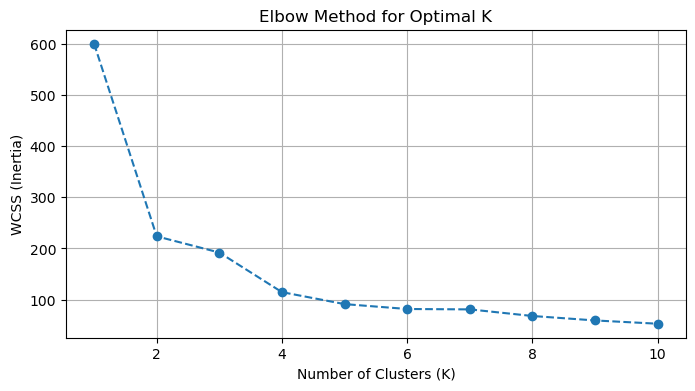

In [35]:
#applying elbow method by wcss
from sklearn.cluster import KMeans, AgglomerativeClustering
wcss = []
for k in range(1,11):
    KM = KMeans(n_clusters=k, random_state=42)
    KM.fit(X_scaled)
    wcss.append(KM.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [36]:
# Justification: The elbow point at K = 3, beyond which WCSS decrease slows down.
optimized_k = 3

In [37]:
KM = KMeans(n_clusters=optimized_k, random_state=42)
labels=KM.fit_predict(X_scaled)

C:\Users\Rudra Pratap Singh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [38]:
print("Cluster Centers (Scaled Features):\n", KM.cluster_centers_)

Cluster Centers (Scaled Features):
 [[ 0.57100359 -0.36600236  0.69108416  0.66322635]
 [-0.80601877  1.33577362 -1.28618375 -1.21026347]
 [-1.31926109 -0.34584225 -1.14482725 -1.1336954 ]]


In [39]:
labels

array([1, 2, 2, 2, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 1, 2, 2, 1,
       1, 2, 1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [40]:
# 4. Compute Silhouette Score and interpret quality
s_score = silhouette_score(X_scaled,labels)
print(f"Silhouette Score for K={optimized_k}: {s_score:.4f}")
# Interpretation: A positive silhouette score indicates strong cluster separation and structure.

Silhouette Score for K=3: 0.4787


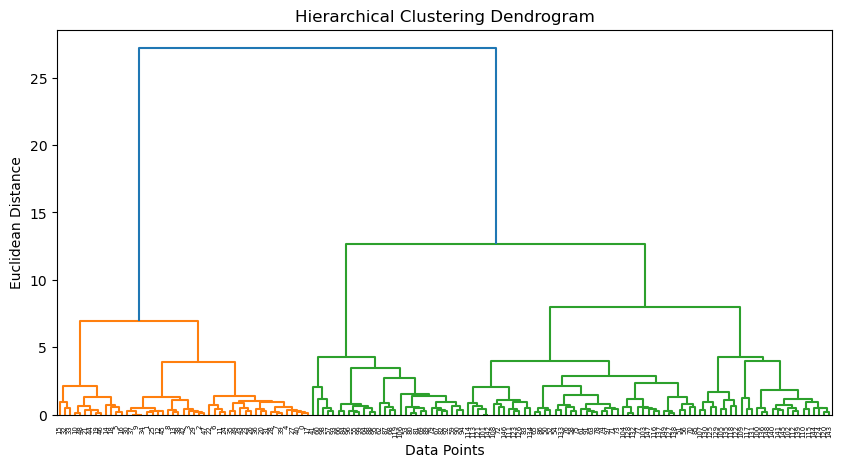

Agglomerative Clustering Silhouette Score: 0.4455


In [41]:
# 5. Apply Agglomerative Hierarchical Clustering
# Fit Agglomerative Clustering using cluster count from Elbow Method
agg = AgglomerativeClustering(n_clusters=optimized_k,metric='euclidean', linkage='ward')
agg_labels = agg.fit_predict(X_scaled)
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()



print(f"Agglomerative Clustering Silhouette Score: {silhouette_score(X_scaled, agg_labels):.4f}")




In [42]:
# the silhoute score in kmeans is greater than silhouette score of agglomerative
# that means k=3 is good

In [43]:
# question 2


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [46]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [47]:
X = df[['area','bedrooms','stories','parking']]
y = df['price']

In [48]:
#1 splited and scaled data 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [49]:
# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

In [50]:
# 2. Implemented Forward Selection
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import SequentialFeatureSelector
lr = LinearRegression()
forward_features = SequentialFeatureSelector(lr, n_features_to_select='auto', direction='forward', cv=5)
forward_features.fit(X_train_scaled, y_train)

forward_selected = X.columns[forward_features.get_support()].tolist()
print("Selected Features:", forward_selected)

Selected Features: ['area', 'stories']


In [51]:
# 3. Implemented backward Selection
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import SequentialFeatureSelector
lr = LinearRegression()
backward_feat = SequentialFeatureSelector(lr, n_features_to_select='auto', direction='backward', cv=5)
backward_feat.fit(X_train_scaled, y_train)

backward_selected = X.columns[backward_feat.get_support()].tolist()
print("Selected Features:", backward_selected)

Selected Features: ['area', 'stories']


In [52]:
# Comparison between Forward and Backward Selection
print("Forward only:", set(forward_selected) - set(backward_selected))
print("Backward only:", set(backward_selected) - set(forward_selected))

Forward only: set()
Backward only: set()


In [53]:
# since both forward and backward are giving same output area,stories there is no difference

In [54]:
# 4. Train Lasso Regression with Alpha Tuning
ls = LassoCV(alphas=np.logspace(-3, 2, 100), cv=5, random_state=42)
ls.fit(X_train_scaled, y_train)

# Identify zero and non-zero coefficients
coef_series = pd.Series(ls.coef_, index=X.columns)
ls_selected = coef_series[coef_series != 0].index.tolist()
shrunk_to_zero = coef_series[coef_series == 0].index.tolist()

print("\n--- Lasso Regression ---")
print(f"Optimal Alpha (penalty): {ls.alpha_:.4f}")
print("Lasso Selected Features:", ls_selected)
print("Features Shrunk to Zero:", shrunk_to_zero)

print("\nCoefficient Values:\n", coef_series)



--- Lasso Regression ---
Optimal Alpha (penalty): 100.0000
Lasso Selected Features: ['area', 'bedrooms', 'stories', 'parking']
Features Shrunk to Zero: []

Coefficient Values:
 area        739568.465541
bedrooms    273270.079217
stories     530571.922342
parking     349826.669068
dtype: float64


In [55]:
# no coefficients shrunks to zero 